In [28]:
# Imports necesarios para el notebook
import random

from matplotlib import pyplot as plt
import seaborn as sns
import numpy as np
import scipy as sp
from John_Jellicoe import algoritmo_JJ
from backtracking import resolver_tablero

from auxiliares import generate_test_case, print_tablero

from util import time_algorithm

# Siempre seteamos la seed de aleatoridad para que los # resultados sean reproducibles
random.seed(12345)
np.random.seed(12345)

sns.set_theme()

In [ ]:
import time

x = np.linspace(10, 300, 15).astype(int) 

offset_n_m = 1
k_boats = 10
num_trials = 1
results = {
    'size': [],
    'jj_time': [],
    'backtrack_time': [],
    'optimality_ratio': [],
    'jj_demand_fulfilled': [],
    'optimal_demand_fulfilled': []
}
worst_ratio =1
worst_parameters = None
for size in x:
    # print(f"Tamaño {size}...")
    size_results = {
        'jj_time': [],
        'backtrack_time': [],
        'optimality_ratio': [],
        'jj_demand': [],
        'opt_demand': []
    }

    for trial in range(num_trials):
        n, m, ship_lengths, row_restrictions, col_restrictions = generate_test_case(offset_n_m, size, k_boats)
        original_row = row_restrictions.copy()
        original_col = col_restrictions.copy()
        total_demand = sum(original_row) + sum(original_col)
        
        print(f"Tamaño {n}x{m} ...")

        start_time = time.time()
        tablero_jj, demanda_restante_jj = algoritmo_JJ(n, m, ship_lengths, row_restrictions.copy(), col_restrictions.copy())
        jj_time = time.time() - start_time
        jj_demand_fulfilled = total_demand - demanda_restante_jj
        
        start_time = time.time()
        result_optimal = resolver_tablero(ship_lengths, original_row, original_col, sum(original_row), sum(original_col))
        backtrack_time = time.time() - start_time
        optimal_demand_fulfilled = result_optimal["demanda_cumplida"]
        
        optimality_ratio = jj_demand_fulfilled / optimal_demand_fulfilled if optimal_demand_fulfilled > 0 else 0
        if optimality_ratio < worst_ratio:
            worst_ratio = optimality_ratio
            worst_parameters = (n, m, ship_lengths, original_row, original_col)
        
        size_results['jj_time'].append(jj_time)
        size_results['backtrack_time'].append(backtrack_time)
        size_results['optimality_ratio'].append(optimality_ratio)
        size_results['jj_demand'].append(jj_demand_fulfilled)
        size_results['opt_demand'].append(optimal_demand_fulfilled)
    
    results['size'].append(size)
    results['jj_time'].append(np.mean(size_results['jj_time']))
    results['backtrack_time'].append(np.mean(size_results['backtrack_time']))
    results['optimality_ratio'].append(np.mean(size_results['optimality_ratio']))
    results['jj_demand_fulfilled'].append(np.mean(size_results['jj_demand']))
    results['optimal_demand_fulfilled'].append(np.mean(size_results['opt_demand']))

print(f"Peor ratio: {worst_ratio} para {worst_parameters}")


Tamaño 10x9 ...
Tamaño 30x31 ...
Tamaño 51x52 ...
Tamaño 72x73 ...
Tamaño 92x91 ...
Tamaño 113x114 ...
Tamaño 134x134 ...
Tamaño 155x156 ...
Tamaño 175x175 ...
Tamaño 196x195 ...
Tamaño 217x216 ...
Tamaño 237x236 ...
Tamaño 258x258 ...
Tamaño 279x280 ...
Tamaño 300x301 ...
Peor ratio: 0.30566037735849055 para (92, 91, [86, 76, 76, 61, 55, 54, 36, 31, 31, 24], [51, 53, 73, 87, 77, 68, 41, 43, 17, 24, 15, 80, 17, 19, 34, 84, 48, 84, 44, 76, 72, 61, 43, 74, 6, 23, 66, 47, 47, 42, 25, 86, 11, 46, 41, 53, 90, 35, 29, 9, 18, 39, 74, 57, 41, 60, 64, 14, 69, 10, 63, 19, 21, 25, 15, 9, 85, 65, 82, 86, 24, 9, 42, 39, 51, 91, 55, 80, 32, 53, 54, 80, 82, 51, 36, 22, 39, 72, 62, 88, 31, 35, 72, 24, 56, 59, 36, 85, 79, 54, 43, 90], [38, 85, 40, 54, 27, 7, 91, 91, 17, 82, 11, 40, 52, 68, 30, 5, 36, 57, 57, 15, 27, 43, 70, 61, 78, 49, 57, 91, 36, 77, 64, 21, 66, 92, 18, 22, 33, 12, 32, 71, 76, 6, 30, 57, 91, 10, 35, 39, 1, 21, 39, 27, 22, 81, 15, 43, 6, 51, 30, 80, 62, 61, 43, 53, 22, 20, 69, 9, 52, 8

In [29]:
board = np.zeros((n, m), dtype=int)

print_tablero(board, worst_parameters[2], worst_parameters[3])

       51  53  73  87  77  68  41  43  17  24  15  80  17  19  34  84  48  84  44  76  72  61  43  74   6  23  66  47  47  42  25  86  11  46  41  53  90  35  29   9  18  39  74  57  41  60  64  14  69  10  63  19  21  25  15   9  85  65  82  86  24   9  42  39  51  91  55  80  32  53  54  80  82  51  36  22  39  72  62  88  31  35  72  24  56  59  36  85  79  54  43  90
     --------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
 86 |    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0  

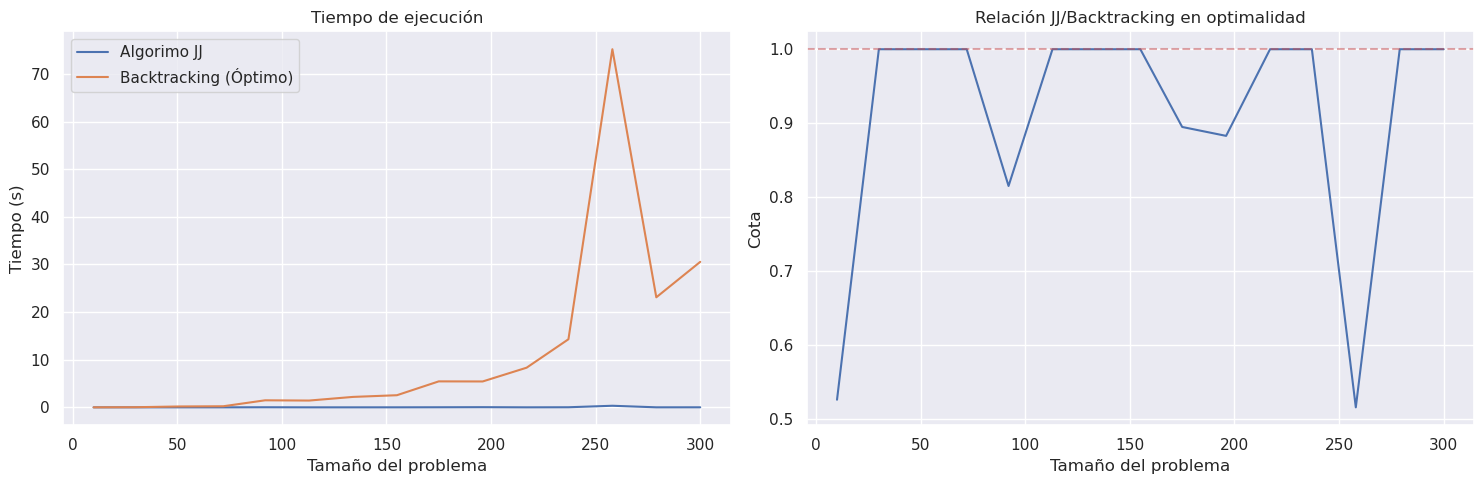

In [24]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(results['size'], results['jj_time'], label='Algorimo JJ')
ax1.plot(results['size'], results['backtrack_time'], label='Backtracking (Óptimo)')
ax1.set_title('Tiempo de ejecución')
ax1.set_xlabel('Tamaño del problema')
ax1.set_ylabel('Tiempo (s)')
ax1.legend()
# ax1.set_yscale('log')

# Plot optimality ratio
ax2.plot(results['size'], results['optimality_ratio'])
ax2.set_title('Relación JJ/Backtracking en optimalidad')
ax2.set_xlabel('Tamaño del problema')
ax2.set_ylabel('Cota')
ax2.axhline(y=1.0, color='r', linestyle='--', alpha=0.5)

plt.tight_layout()
